In [1]:
# use python 3.10 to 3.11 

# Head Pose Estimation — MTCNN + PnP Algorithm
**Repository:** [Face-Yaw-Roll-Pitch-from-Pose-Estimation-using-OpenCV](https://github.com/jerryhouuu/Face-Yaw-Roll-Pitch-from-Pose-Estimation-using-OpenCV)

This notebook evaluates a classical head pose estimation pipeline using **MTCNN** (Multi-task Cascaded Convolutional Networks) for facial landmark detection combined with OpenCV's **solvePnP** algorithm to estimate 3D head orientation. MTCNN detects five facial keypoints — left eye, right eye, nose, and both mouth corners — which are then matched against a generic 3D face model to solve for the rotation vector. The Euler angles (roll, pitch, yaw) are extracted from the resulting rotation matrix.

The pipeline is evaluated on the **FEI Face Database**, a controlled dataset of 200 subjects photographed at 11 head pose angles ranging from -90° to +90° in yaw. The primary benchmark metric is **yaw monotonicity** — whether the model's predicted yaw values strictly increase as the ground truth angle increases across all 11 positions. Pitch and roll are also recorded as secondary stability indicators.

In [18]:
from mtcnn import MTCNN
from mtcnn.utils.images import load_image
from mtcnn.utils.plotting import plot
import matplotlib.pyplot as plt
import math
import numpy as np
import os
from collections import defaultdict
import cv2
from tqdm import tqdm 
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns


dataset_path = "/home/sawaiz/Documents/fyp phase 3/landmark_analysis/dataset/fei dataset"

## Model Initialization & Single Image Sanity Check

The MTCNN detector is initialized on GPU for faster inference. A single test image is run through the detector with high confidence thresholds (`0.99`) on all three network stages (P-Net, R-Net, O-Net) to confirm the pipeline is working before running across the full dataset. The detected landmarks and bounding box are visualized with `plot()`.

In [19]:

mtcnn = MTCNN(device="GPU:0")
image = load_image("1-11.jpg")
result = mtcnn.detect_faces(image, 
threshold_onet=0.99,
threshold_pnet=0.99,
threshold_rnet=0.99
)
result

[{'box': [114, 100, 205, 249],
  'confidence': np.float64(0.9999494552612305),
  'keypoints': {'nose': [np.int64(225), np.int64(238)],
   'mouth_right': [np.int64(264), np.int64(292)],
   'right_eye': [np.int64(269), np.int64(196)],
   'left_eye': [np.int64(176), np.int64(197)],
   'mouth_left': [np.int64(183), np.int64(291)]}}]

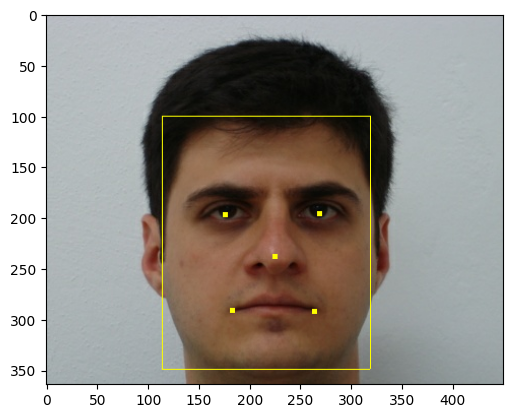

In [20]:
plt.imshow(plot(image, result))
plt.show()

## Head Pose Estimation via PnP (`face_orientation`)

This function implements the core pose estimation logic. It takes a frame and MTCNN's five detected keypoints and maps them to six 2D image points — with the **chin estimated geometrically** since MTCNN does not provide it directly. The chin is approximated by extending the vector from the nose to the mouth center downward by a factor of 2.

These 2D points are matched against a canonical **3D face model** defined in millimetre-scale world coordinates. A pinhole camera model is assumed with a focal length derived from the image width and a 60° field-of-view, and lens distortion is set to zero. OpenCV's `solvePnP` (ITERATIVE flag) solves for the rotation vector, which is then converted to a rotation matrix via Rodrigues, decomposed into Euler angles, and normalized to the [-90°, 90°] range using `arcsin(sin(x))`.

> **Note:** The chin estimation is a heuristic approximation. Its accuracy is sensitive to vertical facial proportions and can introduce pitch/roll noise for faces with non-average geometry.

In [21]:
def face_orientation(frame, landmarks):
    size = frame.shape  #(height, width, color_channel)

    # landmarks order for mtcnn: 
    # left_eye, right_eye, nose, mouth_left, mouth_right
    # Frontal face 6-point order for solvePnP: 
    # [nose, chin, left_eye, right_eye, mouth_left, mouth_right]
    # MTCNN doesn't give chin, so we'll estimate its location:
    nose = landmarks['nose']
    left_eye = landmarks['left_eye']
    right_eye = landmarks['right_eye']
    mouth_left = landmarks['mouth_left']
    mouth_right = landmarks['mouth_right']

    # Estimate chin as midpoint between mouth_left and mouth_right,
    # then extend downward a similar distance from nose to mouth_center
    mouth_center = [(mouth_left[0] + mouth_right[0]) / 2,
                    (mouth_left[1] + mouth_right[1]) / 2]
    chin_y = nose[1] + 2.0 * (mouth_center[1] - nose[1])
    chin = [mouth_center[0], chin_y]

    image_points = np.array([
        (nose[0], nose[1]),               # Nose tip
        (chin[0], chin[1]),               # Chin (approximated)
        (left_eye[0], left_eye[1]),       # Left eye left corner
        (right_eye[0], right_eye[1]),     # Right eye right corner
        (mouth_left[0], mouth_left[1]),   # Left mouth corner
        (mouth_right[0], mouth_right[1])  # Right mouth corner
    ], dtype="double")

    # 3D model points.
    model_points = np.array([
        (0.0, 0.0, 0.0),             # Nose tip
        (0.0, -330.0, -65.0),        # Chin
        (-165.0, 170.0, -135.0),     # Left eye left corner
        (165.0, 170.0, -135.0),      # Right eye right corner
        (-150.0, -150.0, -125.0),    # Left mouth corner
        (150.0, -150.0, -125.0)      # Right mouth corner                         
    ])

    center = (size[1]/2, size[0]/2)
    focal_length = center[0] / np.tan(60/2 * np.pi / 180)
    camera_matrix = np.array(
                        [[focal_length, 0, center[0]],
                         [0, focal_length, center[1]],
                         [0, 0, 1]], dtype = "double")
    dist_coeffs = np.zeros((4,1)) # Assuming no lens distortion

    (success, rotation_vector, translation_vector) = cv2.solvePnP(
        model_points, image_points, camera_matrix, dist_coeffs, flags=cv2.SOLVEPNP_ITERATIVE)

    rvec_matrix = cv2.Rodrigues(rotation_vector)[0]
    proj_matrix = np.hstack((rvec_matrix, translation_vector))
    eulerAngles = cv2.decomposeProjectionMatrix(proj_matrix)[6]

    # Convert eulerAngles to a flat array of floats
    eulerAngles = [float(e[0]) if isinstance(e, np.ndarray) or isinstance(e, np.generic) else float(e) for e in eulerAngles]

    pitch, yaw, roll = [math.radians(_) for _ in eulerAngles]

    pitch = math.degrees(math.asin(math.sin(pitch)))
    roll = -math.degrees(math.asin(math.sin(roll)))
    yaw = math.degrees(math.asin(math.sin(yaw)))

    return (roll, pitch, yaw)

## Full Dataset Inference

The full FEI dataset is processed here — 200 subjects × 11 pose positions each, yielding up to 2,200 images. For each image, MTCNN detects the face, landmarks are extracted, and `face_orientation()` computes the roll, pitch, and yaw angles. Results are stored in two structures:

- `person_pose[person_id][position_label]` — per-person, per-position tuple of `(roll, pitch, yaw)` used for the monotonicity analysis
- `*_angles_by_position` — flat lists of each angle grouped by ground truth position label, used for distribution analysis

Images that fail to load, produce no detection, or raise exceptions during pose estimation are silently skipped and excluded from all downstream metrics.

In [22]:
# Define the ordered positions with their corresponding position codes
ordered_positions = ['90', '75', '60', '45', '30', '-30', '-45', '-60', '-75', '-90', '0']
position_map = {f"{i+1:02d}": pos_label for i, pos_label in enumerate(ordered_positions)}

import time

# Dicts to accumulate roll, pitch, and yaw angles for each position label
yaw_angles_by_position = defaultdict(list)
pitch_angles_by_position = defaultdict(list)
roll_angles_by_position = defaultdict(list)

person_ids = list(range(1, 201))  # assuming 1 to 200
positions = list(range(1, 12))    # image positions 01 to 11

# Store per-person ALL pose angles for every position
person_pose = defaultdict(dict) # person_pose[person_id][position_label] = (roll, pitch, yaw)

# For timing
total_time = 0.0
image_count = 0

for person_id in tqdm(person_ids, desc="Processing Persons"):
    person_prefix = str(person_id)
    for pos_idx, pos in enumerate(positions):
        pos_str = f"{pos:02d}"  # zero-padded position index
        pos_label = ordered_positions[pos_idx]
        img_name = f"{person_prefix}-{pos_str}.jpg"
        img_path = os.path.join(dataset_path, img_name)
        if not os.path.isfile(img_path):
            img_name = f"{person_prefix}-{pos_str}.JPG"
            img_path = os.path.join(dataset_path, img_name)
        if not os.path.isfile(img_path):
            continue  # skip if file doesn't exist

        image = load_image(img_path)
        if image is None:
            continue

        start_time = time.time()
        try:
            result = mtcnn.detect_faces(image)
        except Exception as e:
            continue

        if not result:
            continue

        face = result[0]
        landmarks = face.get("keypoints", {})

        # Convert keypoints to integer lists
        for key in landmarks:
            pt = landmarks[key]
            if isinstance(pt, (np.ndarray, np.generic)) and hasattr(pt, '__iter__'):
                pt = [int(p) for p in pt]
            else:
                pt = [int(v) for v in pt]
            landmarks[key] = pt

        try:
            roll, pitch, yaw = face_orientation(image, landmarks)
            roll_angles_by_position[pos_label].append(roll)
            pitch_angles_by_position[pos_label].append(pitch)
            yaw_angles_by_position[pos_label].append(yaw)
            person_pose[person_id][pos_label] = (roll, pitch, yaw)
            end_time = time.time()
            total_time += (end_time - start_time)
            image_count += 1
        except Exception as e:
            continue  # skip faces where orientation estimation fails

# Print average time per image
if image_count > 0:
    avg_time = total_time / image_count
    print(f"Average time to process an image: {avg_time:.4f} seconds over {image_count} images.")
else:
    print("No images were processed for timing statistics.")

Processing Persons: 100%|██████████| 200/200 [04:05<00:00,  1.23s/it]

Average time to process an image: 0.1090 seconds over 2199 images.


## Evaluation Metric 1 — Monotonic Yaw Increase Check

For a head pose estimator to be considered reliable, predicted yaw values should **strictly increase** as the head rotates from -90° to +90°. Since the FEI dataset captures subjects at physically ordered pose angles, any non-increasing transition — where the predicted yaw stays flat or reverses — indicates the model failed to track the angular change between those two positions.

**Metric:** Count of broken (non-increasing) transitions out of 2000 possible (200 persons × 10 consecutive steps).

> **Note on ground truth:** The intermediate angles (±30°, ±45°, ±60°, ±75°) are approximate visual estimates. Only 0° and ±90° are true ground truth angles. The monotonicity check is therefore the most appropriate primary metric, as it tests directional sensitivity without requiring exact angle calibration.

### Result

The MTCNN + PnP approach produced **265 broken transitions out of 2000**, affecting **157 out of 200 subjects**. While the raw transition failure rate of 13.25% may appear manageable, the breadth of affected subjects — 78.5% of the dataset — reveals that ordering failures are widespread rather than isolated to a few outlier cases. The most severe failures are concentrated at the extreme ends of the yaw range: a recurring pattern of large negative gaps (>100°) at the `-90°→-75°` transition for persons such as 038, 083, 112, 148, 182, 185, and 191 strongly suggests that MTCNN occasionally misidentifies the left/right orientation of a heavily rotated face, causing a sign flip in the yaw estimate. At the positive extreme, the `75°→90°` transition is the single most common failure point, with gaps frequently in the -10° to -27° range, indicating the PnP solver loses angular sensitivity as the face becomes nearly profile. The interior transitions (-30°→0° and 45°→60°) show mostly small gaps under 15°, consistent with the known compression of PnP-derived yaw estimates at mid-range angles. Overall, this method demonstrates reasonable monotonic sensitivity in the central range but breaks down systematically at profile and near-profile poses.


In [ ]:
positions_order = ['-90', '-75', '-60', '-45', '-30', '0', '30', '45', '60', '75', '90']
breaks_info = []  # (person_id, break_index, (previous_yaw, current_yaw))
total_persons_checked = 0
total_gap_instances = 0
total_non_increasing = 0
gaps = []

# To track all gaps per person with a break
person_break_gaps = {}  # person_id -> list of gaps for that person

for person_id in sorted(person_pose.keys()):
    yaws = [person_pose[person_id][pos][2] for pos in positions_order if pos in person_pose[person_id]]
    # Only check if all 10 positions present
    if any(yaw is None for yaw in yaws):
        continue
    total_persons_checked += 1
    person_gaps = []
    for i in range(len(yaws) - 1):
        if yaws[i] >= yaws[i + 1]:
            # Record the first break: index, and values at break
            breaks_info.append((person_id, positions_order[i], yaws[i], positions_order[i+1], yaws[i+1]))
            # Calculate the gap (difference between previous_yaw and current_yaw at break)
            gap = yaws[i+1] - yaws[i]  # should be negative or zero
            gaps.append(gap)
            person_gaps.append(gap)
            total_gap_instances += 1

    if person_gaps:
        total_non_increasing += 1
        person_break_gaps[person_id] = person_gaps

if breaks_info:
    print("Persons and positions where yaw does NOT strictly increase from 01 to 10:")
    for person_id, pos1, yaw1, pos2, yaw2 in breaks_info:
        gap_this_break = yaw2 - yaw1

        print(f" Person {person_id:03d}: Break at {pos1}→{pos2} | yaw: {yaw1:.2f}° → {yaw2:.2f}° | gap: {gap_this_break:.2f}°")
    print(f"\nTotal persons with non-increasing yaw: {total_non_increasing} out of {total_persons_checked}")
    print(f"\nTotal number of non-increasing transitions detected (gap instances): {total_gap_instances} out of {total_persons_checked * (len(positions_order)-1)} possible transitions "
          f"(200 persons × 10 steps = {200*10} transitions)")

else:
    print("All persons have strictly increasing yaw from 01 to 10.")
    print(f"\nTotal persons checked: {total_persons_checked}")

Persons and positions where yaw does NOT strictly increase from 01 to 10:
 Person 002: Break at -75→-60 | yaw: -35.51° → -42.18° | gap: -6.67°
 Person 002: Break at -30→0 | yaw: 7.00° → -6.38° | gap: -13.38°
 Person 002: Break at 75→90 | yaw: 59.15° → 43.65° | gap: -15.50°
 Person 003: Break at -90→-75 | yaw: -46.39° → -50.21° | gap: -3.82°
 Person 004: Break at -60→-45 | yaw: -31.50° → -44.04° | gap: -12.54°
 Person 004: Break at 60→75 | yaw: 52.97° → 39.51° | gap: -13.46°
 Person 005: Break at -75→-60 | yaw: -34.99° → -48.75° | gap: -13.75°
 Person 005: Break at -45→-30 | yaw: -24.21° → -27.94° | gap: -3.73°
 Person 005: Break at 75→90 | yaw: 59.09° → 34.98° | gap: -24.12°
 Person 006: Break at -90→-75 | yaw: -51.78° → -57.61° | gap: -5.83°
 Person 006: Break at 75→90 | yaw: 54.50° → 47.71° | gap: -6.79°
 Person 008: Break at 45→60 | yaw: 40.95° → 24.28° | gap: -16.67°
 Person 008: Break at 75→90 | yaw: 62.37° → 45.43° | gap: -16.94°
 Person 009: Break at -90→-75 | yaw: 73.22° → -42.

## Evaluation Metric 2 — Trimmed Mean Yaw, Pitch & Roll per Position

Computes the **10% trimmed mean** of predicted roll, pitch, and yaw across all 200 subjects at each of the 11 ground truth positions. Trimming removes the top and bottom 10% of values before averaging, making the statistic robust to the outlier sign-flip detections observed in the monotonicity check above.

This metric answers two questions:
1. **Calibration** — does the predicted yaw trend in the right direction and reach a reasonable magnitude at each position?
2. **Stability** — do pitch and roll remain near zero across positions where they should theoretically be constant?

### Result

The trimmed mean yaw values show a clear and consistent monotonic trend across all 11 positions, confirming that the model correctly captures the direction of rotation at the population level. However, there is a pronounced **compression bias** throughout: at ±90° the model predicts only ±57.76° and -61.88° respectively, and at ±75° only ±42.92° and -37.51°, suggesting the PnP solver systematically underestimates yaw magnitude — a well-known consequence of using an approximated chin point and synthetic camera intrinsics rather than calibrated values. The asymmetry between positive and negative extremes (57.76° vs -61.88° at the ±90° positions) likely reflects a slight asymmetry in the chin approximation or landmark placement across left vs right profile views. Pitch shows an unexpected negative dip to **-13.12° at +90°** and a large spike to **-28.20° at -90°**, indicating that the PnP solver conflates out-of-plane rotation with pitch at extreme yaw angles — a geometric ambiguity inherent to single-camera pose estimation. Roll remains close to zero at frontal angles (0.04° at 0°) and increases with yaw, peaking at ±19.90° and -28.80° at the extremes, suggesting some rotational coupling. These pitch and roll deviations at extreme poses are an important stability concern for any application requiring reliable multi-axis estimation.

In [11]:
ordered_positions = ['90', '75', '60', '45', '30', '0', '-30', '-45', '-60', '-75', '-90']
avg_yaw_by_position = {}
avg_pitch_by_position = {}
avg_roll_by_position = {}

# Use a trimmed mean (e.g., trim 10% at each end)
trim_fraction = 0.1

for pos_str in tqdm(ordered_positions, desc="Calculating averages"):
    yaws = yaw_angles_by_position[pos_str]
    pitches = pitch_angles_by_position[pos_str]
    rolls = roll_angles_by_position[pos_str]
    if yaws:
        avg_yaw = trim_mean(yaws, proportiontocut=trim_fraction)
        avg_pitch = trim_mean(pitches, proportiontocut=trim_fraction) if pitches else float('nan')
        avg_roll = trim_mean(rolls, proportiontocut=trim_fraction) if rolls else float('nan')
        avg_yaw_by_position[pos_str] = avg_yaw
        avg_pitch_by_position[pos_str] = avg_pitch
        avg_roll_by_position[pos_str] = avg_roll
        print(f"Position {pos_str}: Trimmed Avg Yaw = {avg_yaw:.2f}°, Pitch = {avg_pitch:.2f}°, Roll = {avg_roll:.2f}° (n={len(yaws)})")
    else:
        print(f"Position {pos_str}: No valid faces found.")


Calculating averages: 100%|██████████| 11/11 [00:00<00:00, 720.84it/s]

Position 90: Trimmed Avg Yaw = 57.76°, Pitch = -13.12°, Roll = 19.90° (n=200)
Position 75: Trimmed Avg Yaw = 42.92°, Pitch = -1.22°, Roll = 10.43° (n=200)
Position 60: Trimmed Avg Yaw = 31.85°, Pitch = 1.23°, Roll = 7.07° (n=200)
Position 45: Trimmed Avg Yaw = 26.01°, Pitch = 2.68°, Roll = 5.71° (n=200)
Position 30: Trimmed Avg Yaw = 14.93°, Pitch = 1.57°, Roll = 2.69° (n=200)
Position 0: Trimmed Avg Yaw = -1.59°, Pitch = 4.28°, Roll = 0.04° (n=200)
Position -30: Trimmed Avg Yaw = -7.75°, Pitch = 4.26°, Roll = -1.23° (n=200)
Position -45: Trimmed Avg Yaw = -21.91°, Pitch = 3.73°, Roll = -4.56° (n=200)
Position -60: Trimmed Avg Yaw = -28.16°, Pitch = 3.59°, Roll = -6.20° (n=200)
Position -75: Trimmed Avg Yaw = -37.51°, Pitch = 0.19°, Roll = -8.74° (n=200)
Position -90: Trimmed Avg Yaw = -61.88°, Pitch = -28.20°, Roll = -28.80° (n=199)


## Evaluation Metric 3 — Yaw Distribution per Position

Plots the full distribution of predicted yaw values across all 200 subjects for each of the 11 ground truth positions. Each subplot shows a histogram with a KDE overlay, along with vertical lines marking the raw mean and 10% trimmed mean.

This visualization captures what the trimmed mean table cannot: the **shape, spread, and outlier structure** of predictions at each angle. Bimodal distributions, heavy tails, or large standard deviations at a given position indicate inconsistent model behaviour across subjects — not just a systematic offset.

### Result

The distribution plots reveal a clear and consistent story about how the MTCNN + PnP pipeline behaves across the full yaw range. At the **frontal position (0°)**, the distribution is the tightest of all positions, forming a clean unimodal peak centred near 0° with a std of 6.78° — this is the model's most reliable operating point. Moving outward to **±30° and ±45°**, distributions remain unimodal and reasonably compact (std ~8–10°), though a compression bias is already visible: the predicted means of 15.38° and -8.06° / -22.28° fall noticeably short of their ground truth targets. At **±60°**, the distributions begin to widen and flatten (std ~10–11°), with the mass shifting further from the true angle, and a light left tail begins to appear on the positive side.

The most significant degradation occurs at **±75° and ±90°**. At +75° and +90°, the distributions develop a pronounced **right-skewed shape with a long left tail**, and the raw mean diverges from the trimmed mean (e.g., 57.44° vs 57.76° at 90°, and 43.20° vs 42.92° at 75°) — indicating a small but meaningful cluster of outlier predictions pulling the distribution leftward. The std at 90° reaches **17.40°**, the highest of any position, reflecting genuine inconsistency across subjects at near-profile poses.

The negative side tells a more dramatic story. At **-75°** (std=12.55°) and especially **-90°** (std=37.61°), the distributions become heavily spread and clearly **bimodal**. The -90° plot shows a dominant cluster around -50° to -60° but also a visible secondary cluster near +40° to +70° — these are the sign-flip failures from the monotonicity analysis, where the model predicts a large positive yaw for a fully left-profile face. The -90° trimmed mean of -61.88° vs the raw mean of -52.70° highlights how much these outliers inflate the raw statistic. This asymmetry between positive and negative extremes — where the negative side is considerably noisier — suggests the MTCNN landmark detector or the chin approximation geometry is less stable for left-facing profiles than right-facing ones.

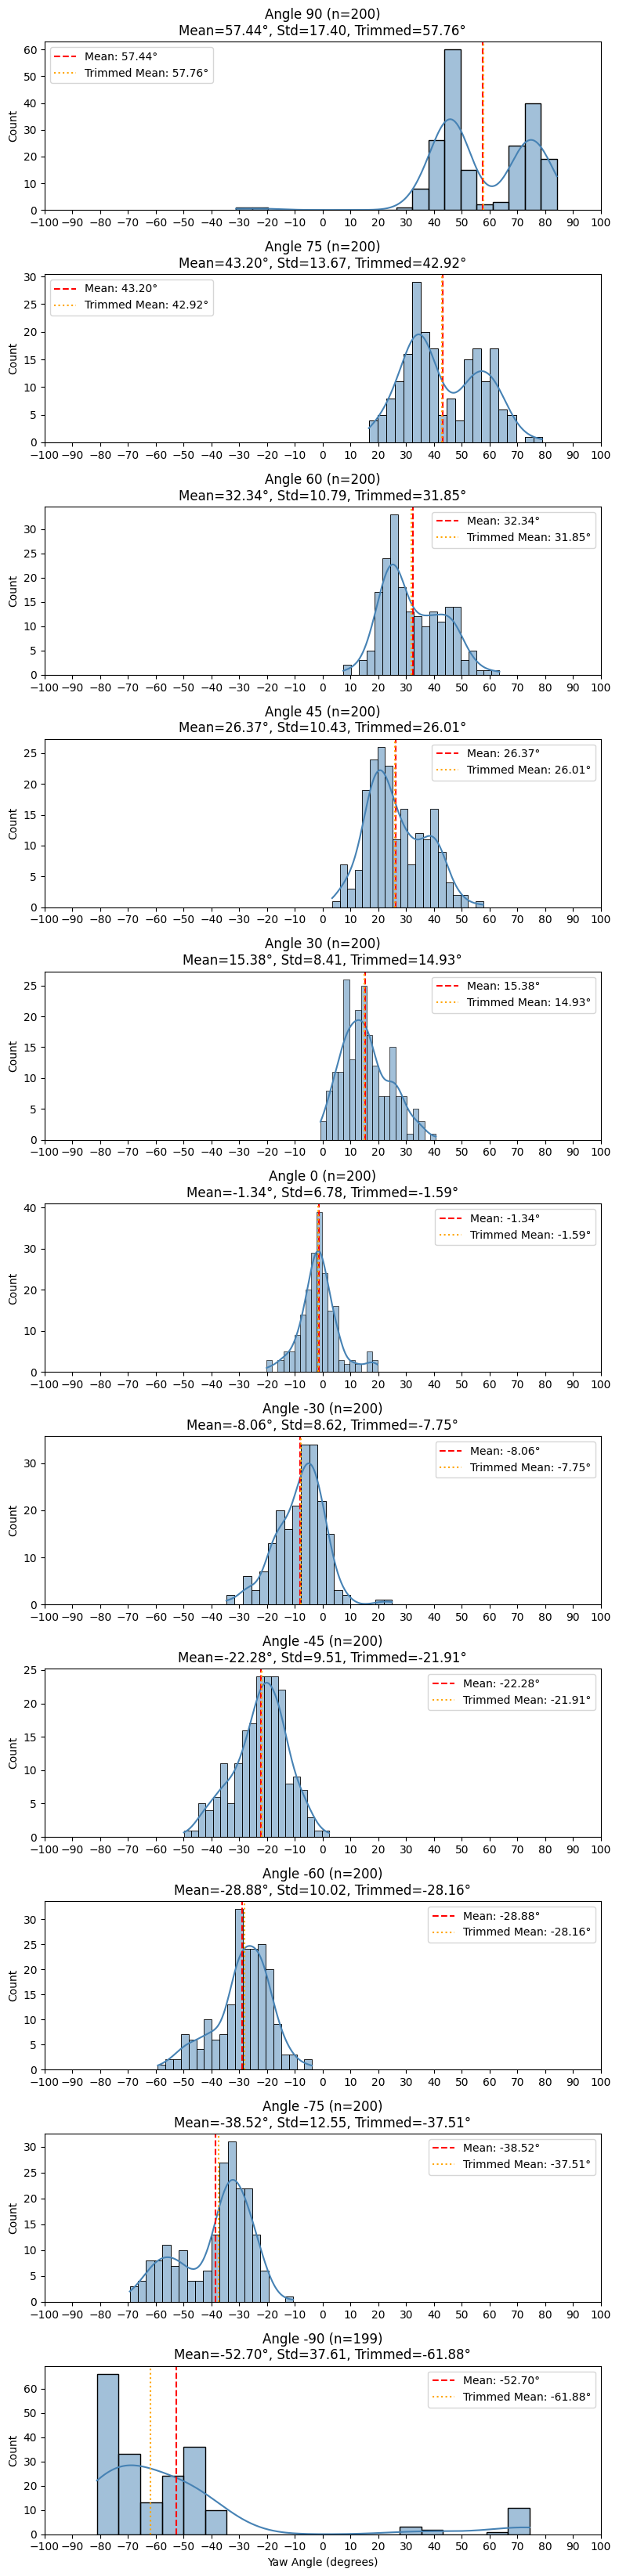

In [12]:
positions_order = ['90', '75', '60', '45', '30', '0', '-30', '-45', '-60', '-75', '-90']

# Prepare for plotting
positions = sorted(yaw_angles_by_position.keys())

fig, axes = plt.subplots(len(positions), 1, figsize=(8, 3 * len(positions)), sharex=True)

if len(positions) == 1:
    axes = [axes]  # in case only one position

for idx, pos_str in enumerate(positions_order):
    yaws = yaw_angles_by_position[pos_str]
    ax = axes[idx]
    if yaws:
        sns.histplot(yaws, bins=20, kde=True, ax=ax, color='steelblue')
        mean = np.mean(yaws)
        trimmed = trim_mean(yaws, proportiontocut=0.1)
        std = np.std(yaws)
        n = len(yaws)
        ax.axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.2f}°")
        ax.axvline(trimmed, color='orange', linestyle=':', label=f"Trimmed Mean: {trimmed:.2f}°")
        ax.set_title(f"Angle {pos_str} (n={n})\nMean={mean:.2f}°, Std={std:.2f}, Trimmed={trimmed:.2f}°")

        # Set the x-axis limits from -90 to 90 as requested
        ax.set_xlim(-100, 100)

        # Set x-axis ticks every 10 degrees
        ax.set_xticks(np.arange(-100, 101, 10))

        # Ensures y axis shows tick labels for each plot clearly
        ax.tick_params(axis='y', which='both', labelleft=True, left=True)
        ax.yaxis.set_tick_params(labelleft=True)
        ax.set_ylabel("Count")

        # Ensure x-axis and y-axis tick labels are visible and not overlapped
        ax.tick_params(axis='x', which='both', labelbottom=True, bottom=True, labelsize=10, rotation=0)
        ax.xaxis.set_tick_params(labelbottom=True)
        for label in ax.get_xticklabels():
            label.set_visible(True)
            label.set_fontsize(10)
            label.set_rotation(0)

        ax.legend()
        
    else:
        ax.set_title(f"Position {pos_str}: No valid data")
        ax.axis('off')

    # Set x-axis label for every axes (even for 'off' axes for consistency)
    ax.set_xlabel("Yaw Angle (degrees)")

# Redraw to ensure all ticks and labels are correctly applied
plt.tight_layout()
plt.show()